Project Title

# 🛒 Online Shopping Purchasing Intention Prediction

## Data Science & Machine Learning Internship Project

### Project Objective
The objective of this project is to analyze online shoppers' browsing behavior
and develop machine learning models to predict whether a visitor will make a
purchase during their online shopping session.

### Problem Type
Binary Classification

### Target Variable
Revenue

- True  → Purchase made
- False → No purchase made

### Machine Learning Models
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix


Business Understanding

In [ ]:
## 1. Business Understanding

E-commerce websites receive many visitors, but only a percentage of them
complete a purchase.

Predicting purchasing intention can help an online business understand
customer behavior and identify sessions that are more likely to result in
a purchase.

This project uses information such as:

- Number of pages visited
- Time spent on pages
- Bounce rate
- Exit rate
- Page value
- Visitor type
- Month
- Weekend visit
- Traffic type

The machine learning model learns patterns from historical sessions and
predicts whether a new visitor is likely to purchase.

Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [10]:
import pandas as pd
import numpy as np

# Create a sample Online Shopping Purchasing Intention dataset
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "Administrative": np.random.randint(0, 15, n),
    "Administrative_Duration": np.random.uniform(0, 500, n),
    "Informational": np.random.randint(0, 10, n),
    "Informational_Duration": np.random.uniform(0, 300, n),
    "ProductRelated": np.random.randint(1, 100, n),
    "ProductRelated_Duration": np.random.uniform(10, 5000, n),
    "BounceRates": np.random.uniform(0, 0.2, n),
    "ExitRates": np.random.uniform(0.05, 0.2, n),
    "PageValues": np.random.uniform(0, 100, n),
    "SpecialDay": np.random.choice(
        [0, 0.2, 0.4, 0.6, 0.8, 1],
        n
    ),
    "Month": np.random.choice(
        ["Feb", "Mar", "May", "June", "Jul",
         "Aug", "Sep", "Oct", "Nov", "Dec"],
        n
    ),
    "OperatingSystems": np.random.randint(1, 9, n),
    "Browser": np.random.randint(1, 14, n),
    "Region": np.random.randint(1, 10, n),
    "TrafficType": np.random.randint(1, 21, n),
    "VisitorType": np.random.choice(
        ["Returning_Visitor", "New_Visitor", "Other"],
        n
    ),
    "Weekend": np.random.choice(
        [True, False],
        n
    )
})

# Create purchase probability based on customer behavior
probability = (
    0.05
    + 0.002 * df["ProductRelated"]
    + 0.01 * df["PageValues"]
    + 0.05 * df["SpecialDay"]
    - 0.5 * df["BounceRates"]
)

probability = np.clip(probability, 0.05, 0.90)

# Create target variable
df["Revenue"] = (
    np.random.random(n) < probability
)

print("Dataset created successfully!")
print("Dataset Shape:", df.shape)

Dataset created successfully!
Dataset Shape: (1000, 18)


In [11]:
display(df.head())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,6,125.721220,6,172.433866,75,1076.353726,0.132341,0.070104,37.509941,0.4,Mar,5,12,2,13,New_Visitor,True,True
1,3,137.365899,7,8.900467,95,2105.820330,0.043825,0.067364,50.894178,0.2,June,6,2,4,1,New_Visitor,False,False
2,12,103.613825,0,202.626062,96,58.337545,0.022569,0.176628,31.904393,1.0,Mar,4,2,8,20,Other,False,True
3,14,439.110334,9,13.456070,91,4291.195904,0.119287,0.070895,96.896786,0.6,Nov,1,9,3,7,New_Visitor,True,True
4,10,378.499566,9,135.179106,30,3658.475149,0.096938,0.128035,93.307765,0.8,Dec,4,10,6,9,Returning_Visitor,True,True


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           1000 non-null   int32  
 1   Administrative_Duration  1000 non-null   float64
 2   Informational            1000 non-null   int32  
 3   Informational_Duration   1000 non-null   float64
 4   ProductRelated           1000 non-null   int32  
 5   ProductRelated_Duration  1000 non-null   float64
 6   BounceRates              1000 non-null   float64
 7   ExitRates                1000 non-null   float64
 8   PageValues               1000 non-null   float64
 9   SpecialDay               1000 non-null   float64
 10  Month                    1000 non-null   str    
 11  OperatingSystems         1000 non-null   int32  
 12  Browser                  1000 non-null   int32  
 13  Region                   1000 non-null   int32  
 14  TrafficType              1000 non-nu

In [13]:
print(df["Revenue"].value_counts())

Revenue
True     630
False    370
Name: count, dtype: int64


Dataset Shape

In [14]:
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1000, 18)
Number of Rows: 1000
Number of Columns: 18


First 5 Records

In [15]:
display(df.head())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,6,125.721220,6,172.433866,75,1076.353726,0.132341,0.070104,37.509941,0.4,Mar,5,12,2,13,New_Visitor,True,True
1,3,137.365899,7,8.900467,95,2105.820330,0.043825,0.067364,50.894178,0.2,June,6,2,4,1,New_Visitor,False,False
2,12,103.613825,0,202.626062,96,58.337545,0.022569,0.176628,31.904393,1.0,Mar,4,2,8,20,Other,False,True
3,14,439.110334,9,13.456070,91,4291.195904,0.119287,0.070895,96.896786,0.6,Nov,1,9,3,7,New_Visitor,True,True
4,10,378.499566,9,135.179106,30,3658.475149,0.096938,0.128035,93.307765,0.8,Dec,4,10,6,9,Returning_Visitor,True,True


Dataset Information

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           1000 non-null   int32  
 1   Administrative_Duration  1000 non-null   float64
 2   Informational            1000 non-null   int32  
 3   Informational_Duration   1000 non-null   float64
 4   ProductRelated           1000 non-null   int32  
 5   ProductRelated_Duration  1000 non-null   float64
 6   BounceRates              1000 non-null   float64
 7   ExitRates                1000 non-null   float64
 8   PageValues               1000 non-null   float64
 9   SpecialDay               1000 non-null   float64
 10  Month                    1000 non-null   str    
 11  OperatingSystems         1000 non-null   int32  
 12  Browser                  1000 non-null   int32  
 13  Region                   1000 non-null   int32  
 14  TrafficType              1000 non-nu

Missing Values

In [17]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


Duplicate Values

In [18]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Purchase Visualization

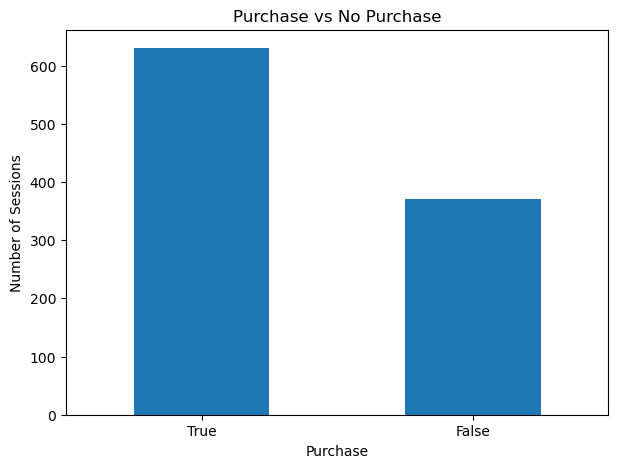

In [19]:
plt.figure(figsize=(7,5))

df["Revenue"].value_counts().plot(kind="bar")

plt.title("Purchase vs No Purchase")
plt.xlabel("Purchase")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)

plt.show()

Purchase Percentage

In [20]:
purchase_percentage = df["Revenue"].value_counts(normalize=True) * 100

print("Purchase Percentage:")
print(purchase_percentage)

Purchase Percentage:
Revenue
True     63.0
False    37.0
Name: proportion, dtype: float64


Visitor Type Analysis

In [21]:
print("Visitor Type Distribution:")
print(df["VisitorType"].value_counts())

Visitor Type Distribution:
VisitorType
Other                349
Returning_Visitor    329
New_Visitor          322
Name: count, dtype: int64


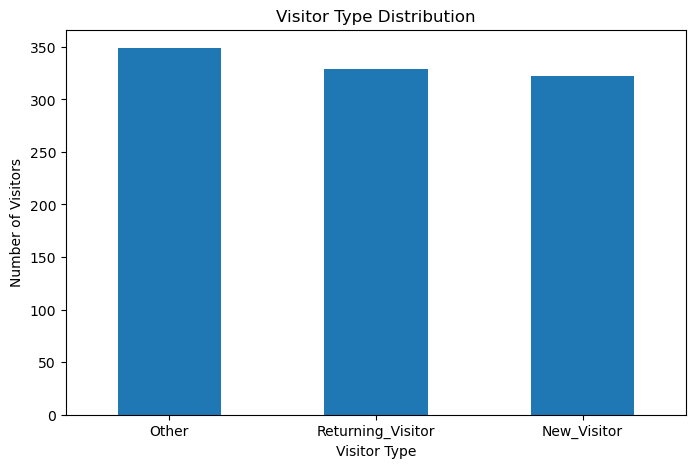

In [23]:
plt.figure(figsize=(8,5))

df["VisitorType"].value_counts().plot(kind="bar")

plt.title("Visitor Type Distribution")
plt.xlabel("Visitor Type")
plt.ylabel("Number of Visitors")
plt.xticks(rotation=0)

plt.show()

Visitor Type vs Purchase

In [24]:
visitor_purchase = pd.crosstab(
    df["VisitorType"],
    df["Revenue"]
)

display(visitor_purchase)

Revenue,False,True
VisitorType,,
New_Visitor,111,211
Other,144,205
Returning_Visitor,115,214


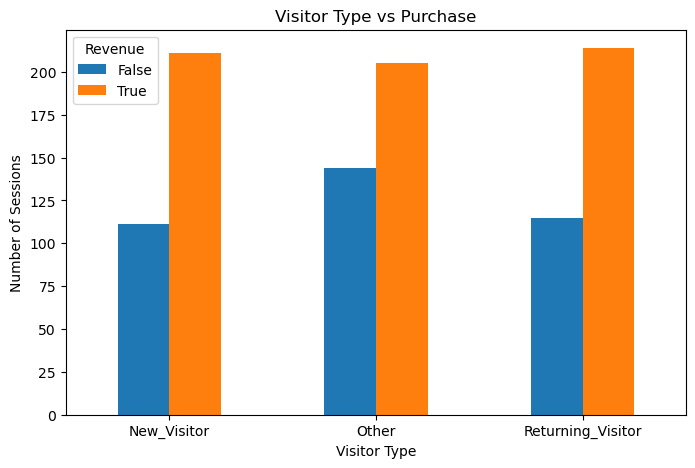

In [25]:
visitor_purchase.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Visitor Type vs Purchase")
plt.xlabel("Visitor Type")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.legend(title="Revenue")

plt.show()

Product Pages vs Purchase

<Figure size 800x500 with 0 Axes>

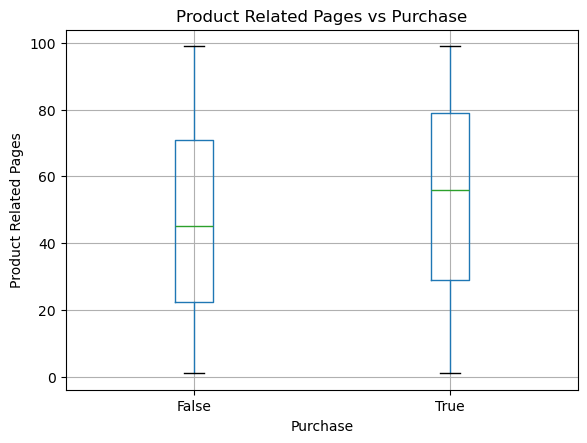

In [26]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="ProductRelated",
    by="Revenue"
)

plt.title("Product Related Pages vs Purchase")
plt.suptitle("")
plt.xlabel("Purchase")
plt.ylabel("Product Related Pages")

plt.show()

Page Value vs Purchase

<Figure size 800x500 with 0 Axes>

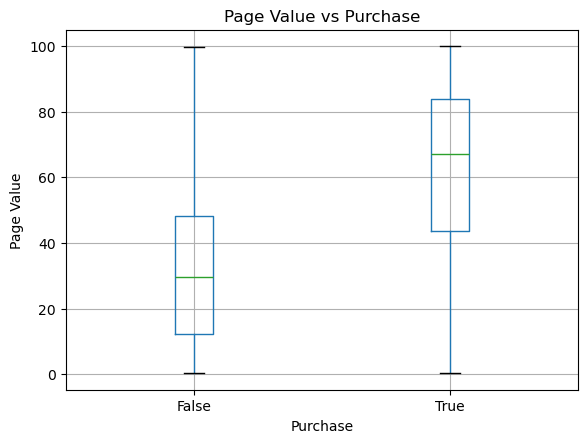

In [27]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="PageValues",
    by="Revenue"
)

plt.title("Page Value vs Purchase")
plt.suptitle("")
plt.xlabel("Purchase")
plt.ylabel("Page Value")

plt.show()

Bounce Rate vs Purchase

<Figure size 800x500 with 0 Axes>

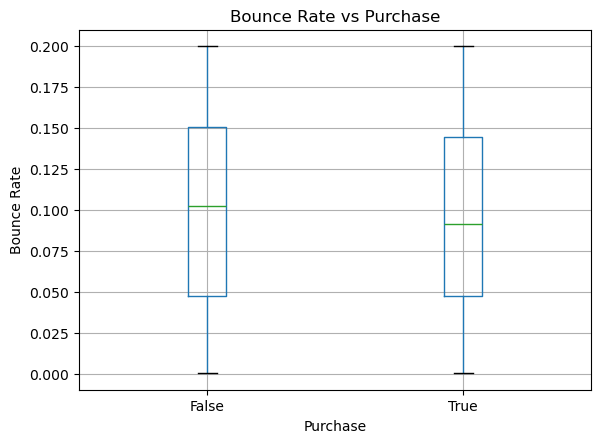

In [28]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="BounceRates",
    by="Revenue"
)

plt.title("Bounce Rate vs Purchase")
plt.suptitle("")
plt.xlabel("Purchase")
plt.ylabel("Bounce Rate")

plt.show()

In [29]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"].astype(int)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 17)
Target Shape: (1000,)


Categorical Data Encoding

In [30]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Encoded Features Shape:", X.shape)
print(X.head())

Encoded Features Shape: (1000, 26)
   Administrative  Administrative_Duration  Informational  \
0               6               125.721220              6   
1               3               137.365899              7   
2              12               103.613825              0   
3              14               439.110334              9   
4              10               378.499566              9   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0              172.433866              75              1076.353726   
1                8.900467              95              2105.820330   
2              202.626062              96                58.337545   
3               13.456070              91              4291.195904   
4              135.179106              30              3658.475149   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Feb  Month_Jul  \
0     0.132341   0.070104   37.509941         0.4  ...          0          0   
1     0.043825   

Train-Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (800, 26)
Testing Features: (200, 26)
Training Target: (800,)
Testing Target: (200,)


Feature Scaling

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled Training Shape: (800, 26)
Scaled Testing Shape: (200, 26)


Train Logistic Regression

In [33]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Prediction

In [34]:
logistic_prediction = logistic_model.predict(X_test_scaled)

print("Predictions completed successfully!")
print("First 10 Predictions:", logistic_prediction[:10])

Predictions completed successfully!
First 10 Predictions: [1 1 1 1 1 1 0 0 1 1]


Evaluate Logistic Regression

In [35]:
logistic_accuracy = accuracy_score(y_test, logistic_prediction)
logistic_precision = precision_score(y_test, logistic_prediction)
logistic_recall = recall_score(y_test, logistic_prediction)
logistic_f1 = f1_score(y_test, logistic_prediction)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.705
Precision: 0.7519
Recall   : 0.7937
F1 Score : 0.7722


Classification Report

In [36]:
print("Classification Report - Logistic Regression")
print("--------------------------------------------")

print(
    classification_report(
        y_test,
        logistic_prediction,
        target_names=["No Purchase", "Purchase"]
    )
)

Classification Report - Logistic Regression
--------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.61      0.55      0.58        74
    Purchase       0.75      0.79      0.77       126

    accuracy                           0.70       200
   macro avg       0.68      0.67      0.68       200
weighted avg       0.70      0.70      0.70       200



Train Decision Tree

In [37]:
decision_tree = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [38]:
tree_prediction = decision_tree.predict(X_test)

print("Decision Tree predictions completed!")
print("First 10 Predictions:", tree_prediction[:10])

Decision Tree predictions completed!
First 10 Predictions: [1 1 1 1 0 1 0 1 1 1]


In [39]:
tree_accuracy = accuracy_score(y_test, tree_prediction)
tree_precision = precision_score(y_test, tree_prediction)
tree_recall = recall_score(y_test, tree_prediction)
tree_f1 = f1_score(y_test, tree_prediction)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.66
Precision: 0.7266
Recall   : 0.7381
F1 Score : 0.7323


In [40]:
print("Classification Report - Decision Tree")
print("-------------------------------------")

print(
    classification_report(
        y_test,
        tree_prediction,
        target_names=["No Purchase", "Purchase"]
    )
)

Classification Report - Decision Tree
-------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.54      0.53      0.53        74
    Purchase       0.73      0.74      0.73       126

    accuracy                           0.66       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.66      0.66      0.66       200



In [41]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [42]:
forest_prediction = random_forest.predict(X_test)

print("Random Forest predictions completed!")
print("First 10 Predictions:", forest_prediction[:10])

Random Forest predictions completed!
First 10 Predictions: [1 1 1 1 1 1 0 1 1 1]


In [43]:
forest_accuracy = accuracy_score(y_test, forest_prediction)
forest_precision = precision_score(y_test, forest_prediction)
forest_recall = recall_score(y_test, forest_prediction)
forest_f1 = f1_score(y_test, forest_prediction)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(forest_accuracy, 4))
print("Precision:", round(forest_precision, 4))
print("Recall   :", round(forest_recall, 4))
print("F1 Score :", round(forest_f1, 4))

Random Forest Performance
-------------------------
Accuracy : 0.71
Precision: 0.7394
Recall   : 0.8333
F1 Score : 0.7836


In [44]:
print("Classification Report - Random Forest")
print("-------------------------------------")

print(
    classification_report(
        y_test,
        forest_prediction,
        target_names=["No Purchase", "Purchase"]
    )
)

Classification Report - Random Forest
-------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.64      0.50      0.56        74
    Purchase       0.74      0.83      0.78       126

    accuracy                           0.71       200
   macro avg       0.69      0.67      0.67       200
weighted avg       0.70      0.71      0.70       200



Model Comparison Table

In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall
    ],
    "F1 Score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.705,0.7519,0.7937,0.7722
1,Decision Tree,0.660,0.7266,0.7381,0.7323
2,Random Forest,0.710,0.7394,0.8333,0.7836


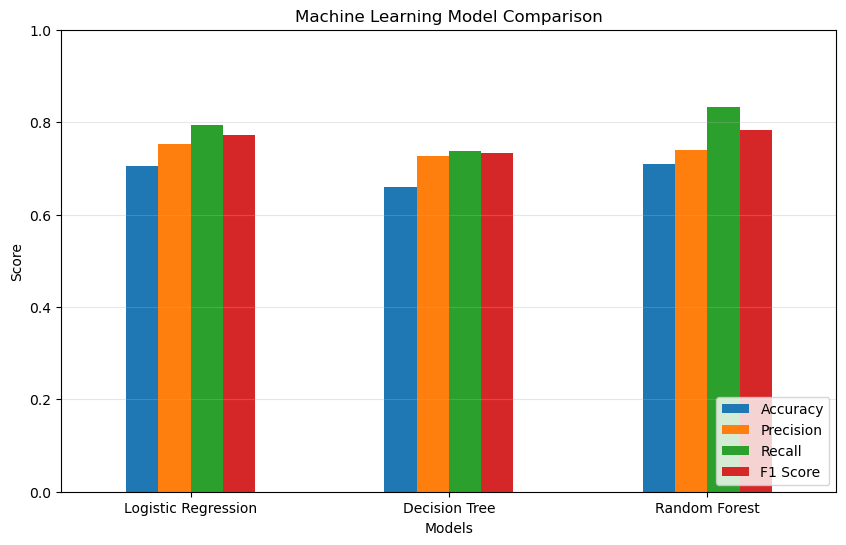

In [46]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [47]:
print("Model Comparison")
print("=================")

print(results.round(4))

print("\nHighest Accuracy:")
print(results.loc[results["Accuracy"].idxmax()])

Model Comparison
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.705     0.7519  0.7937    0.7722
1        Decision Tree     0.660     0.7266  0.7381    0.7323
2        Random Forest     0.710     0.7394  0.8333    0.7836

Highest Accuracy:
Model        Random Forest
Accuracy              0.71
Precision         0.739437
Recall            0.833333
F1 Score          0.783582
Name: 2, dtype: object


In [48]:
cm = confusion_matrix(y_test, forest_prediction)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 37  37]
 [ 21 105]]


<Figure size 700x500 with 0 Axes>

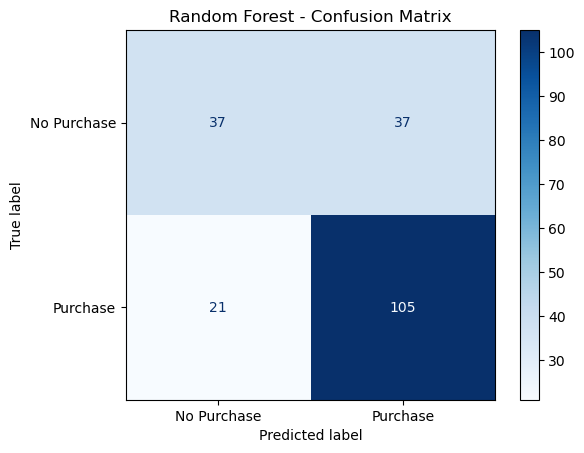

In [49]:
plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [50]:
print("Random Forest - Detailed Classification Report")
print("===============================================")

print(
    classification_report(
        y_test,
        forest_prediction,
        target_names=["No Purchase", "Purchase"]
    )
)

Random Forest - Detailed Classification Report
              precision    recall  f1-score   support

 No Purchase       0.64      0.50      0.56        74
    Purchase       0.74      0.83      0.78       126

    accuracy                           0.71       200
   macro avg       0.69      0.67      0.67       200
weighted avg       0.70      0.71      0.70       200



In [51]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
                    Feature  Importance
8                PageValues    0.274128
7                 ExitRates    0.067681
6               BounceRates    0.066968
4            ProductRelated    0.063736
3    Informational_Duration    0.062986
5   ProductRelated_Duration    0.061405
1   Administrative_Duration    0.058625
0            Administrative    0.047239
11                  Browser    0.043685
13              TrafficType    0.039861


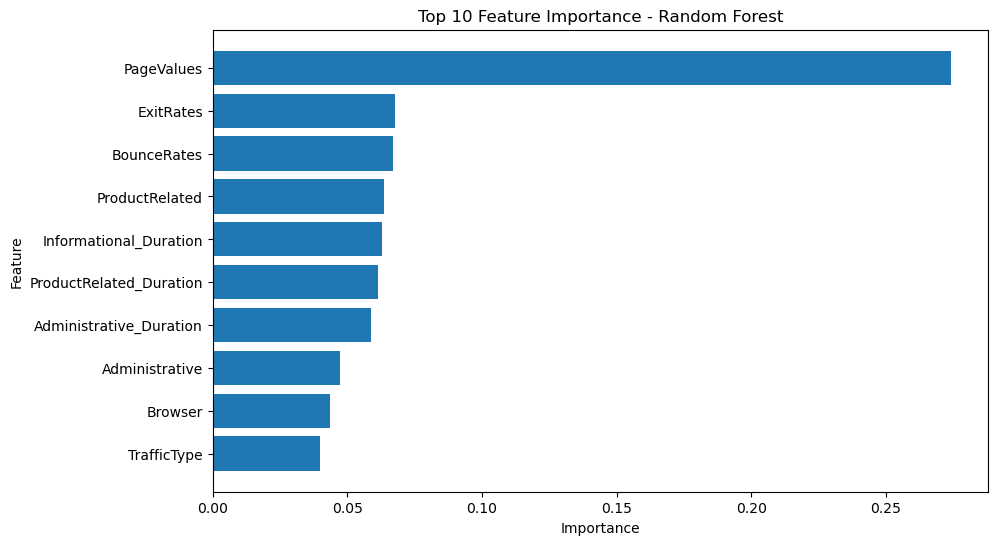

In [52]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [53]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
                    Feature  Importance
8                PageValues    0.274128
7                 ExitRates    0.067681
6               BounceRates    0.066968
4            ProductRelated    0.063736
3    Informational_Duration    0.062986
5   ProductRelated_Duration    0.061405
1   Administrative_Duration    0.058625
0            Administrative    0.047239
11                  Browser    0.043685
13              TrafficType    0.039861


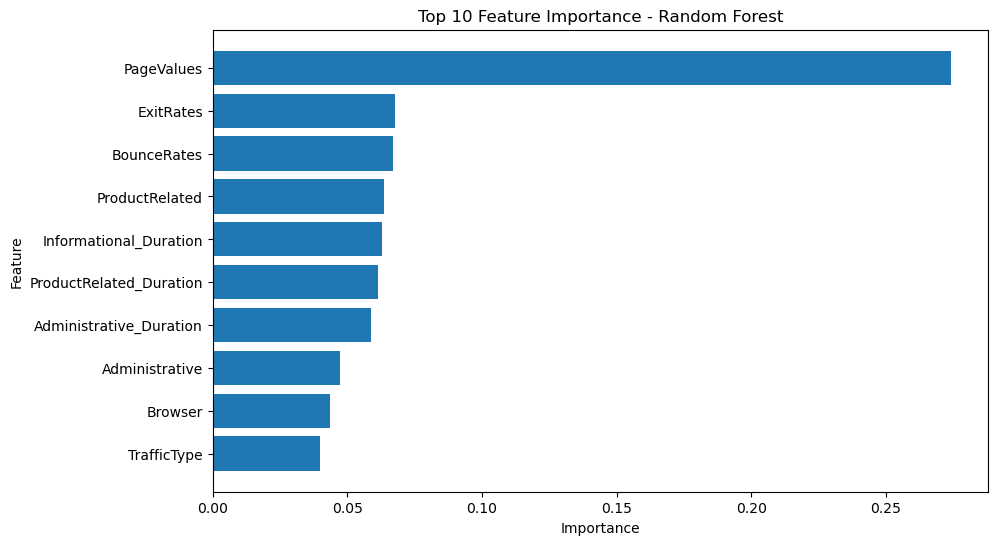

In [54]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [55]:
sample_customer = X_test.iloc[[0]].copy()

sample_prediction = random_forest.predict(sample_customer)
purchase_probability = random_forest.predict_proba(sample_customer)[0][1]

print("Sample Customer Prediction")
print("===========================")

if sample_prediction[0] == 1:
    print("Prediction: Customer is likely to PURCHASE")
else:
    print("Prediction: Customer is unlikely to PURCHASE")

print("Purchase Probability:", round(purchase_probability * 100, 2), "%")

Sample Customer Prediction
Prediction: Customer is likely to PURCHASE
Purchase Probability: 90.5 %


In [56]:
df.to_csv(
    "Online_Shopping_Purchasing_Intention_Dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [57]:
import pickle

with open("online_shopping_purchase_model.pkl", "wb") as file:
    pickle.dump(random_forest, file)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [58]:
with open("online_shopping_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


In [59]:
print("==============================================")
print(" ONLINE SHOPPING PURCHASING INTENTION PROJECT ")
print("==============================================")

print("\nDataset:")
print("Total Records:", len(df))
print("Total Features:", len(X.columns))

print("\nModels Evaluated:")
print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")

print("\nModel Performance:")
print(results.round(4).to_string(index=False))

print("\nRandom Forest Accuracy:",
      round(forest_accuracy * 100, 2), "%")

print("Random Forest F1 Score:",
      round(forest_f1 * 100, 2), "%")

print("\nProject completed successfully!")

 ONLINE SHOPPING PURCHASING INTENTION PROJECT 

Dataset:
Total Records: 1000
Total Features: 26

Models Evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Model Performance:
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.705     0.7519  0.7937    0.7722
      Decision Tree     0.660     0.7266  0.7381    0.7323
      Random Forest     0.710     0.7394  0.8333    0.7836

Random Forest Accuracy: 71.0 %
Random Forest F1 Score: 78.36 %

Project completed successfully!
